# First Look: `quicklook` and `report`

You have a simulation output and no idea what is in it. This page is about the first two minutes.

Mera has two entry points for that, and the difference between them is the first thing to get
straight:

| | `quicklook` | `report` |
|---|---|---|
| what it is | one fixed dashboard | a set of cards you choose |
| how you call it | one function, a few switches | build a plan, then run it |
| what you get | Σ maps, a ρ-T phase diagram, a census | whatever cards you put in the plan |
| cost control | `budget`, `lmax`, `datatypes` | a cost model: `estimate`, `preview`, `downsample` |
| use it when | you do not yet know what you are looking at | you know what you want to see |

Start with `quicklook`. Move to `report` when you find yourself wanting a panel it does not have.

Everything below runs on a real Milky-Way-like RAMSES run: **640 CPU domains, 2569 files, 5.7 GB
on disk**. That matters, because the honest answer to "how long does a first look take" depends
almost entirely on how many files there are.

## Setup

Point `MERA_EXAMPLES` at your own simulation folder, or edit the path below.

In [1]:
using Mera

MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests")
path = "$MERA_EXAMPLES/RAMSES/mw_L10"
output = 300;


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0 | Julia 1.12.7 | 8 threads



## Step 1: what you get for free

`read=false` reads only the header. No cell is touched, no particle is read, and it returns
immediately whatever the size of the run. This is the cheapest thing Mera can tell you, and it is
often enough to decide what to do next.

In [2]:
q0 = quicklook(output; path=path, read=false);

┌─ Mera quicklook ── output 300 (RAMSES) ───────────────


│ box        : 48.0 kpc      levels 6–10  (finest 46.88 pc)
│ grid       : ndim 3 · ncpu 640 · nvarh 7
│ time       : 445.9 Myr  (non-cosmological)
│ particles  : 544515 total  —  stars 544515 · DM 0
│ (header only — call quicklook(output) to read a sample)
└─ 0.15 s ──────────────────────────────────


Note what is already known: the box size, the AMR level range and therefore the finest cell, the
time or redshift, the number of CPU domains, and the particle census by family. The cell count is
*not* there, because RAMSES does not record a leaf-cell total in the header; `grid_info.ngrid_current`
is not it. Cells are reported only after a read.

The `ncpu` line is the number to look at before a big read. It is the count of per-CPU files Mera
will have to open, and on large runs it dominates everything else.

## Step 2: the actual first look

Now the real call. On a run this size it is not instant, so Mera says what it is doing:

- a timestamped line before each read, naming the file count and the level range
- the reader's own progress bar, with a file rate and an ETA
- a line before the projections
- the dashboard, with the elapsed time in its footer
- a closing timestamp

If your terminal is silent, the call is not running.

In [3]:
q = quicklook(output; path=path);

[Mera]: quicklook output 300, reading gas: 2026-09-09T18:46:06.212



   640 CPU file(s), levels 6-8 of 10  (budgeted to ~2000000 cells)


Processing files:   0%|                                                  |  ETA: N/A (  N/A  s/it)

Processing files:   1%|▊                                                 |  ETA: 0:00:58 (91.47 ms/it)

Processing files:   2%|▉                                                 |  ETA: 0:00:56 (89.71 ms/it)

...


✓ File processing complete! Combining results...


   projecting 3 gas map(s) [z, x, y] and the phase diagram from 9959076 cells


[Mera]: quicklook output 300, reading particles: 2026-09-09T18:46:25.464



[ Info: sfr_snapshot: using eta_sn=0.2 from the run's namelist to rebuild birth masses from the current :mass. Stars older than 5.0 Myr are scaled by 1/(1-eta_sn), which RAISES the rate. Pass eta_sn=0 to switch this off, or eta_sn=<value> to set it.


┌─ Mera quicklook ── output 300 (RAMSES) ───────────────
│ box        : 48.0 kpc      levels 6–10  (finest 46.88 pc)
│ grid       : ndim 3 · ncpu 640 · nvarh 7
│ time       : 445.9 Myr  (non-cosmological)
│ particles  : 544515 total  —  stars 544515 · DM 0
│ read       : 9959076 cells  ⚠ coarse levels ≤ 8 of 10
│ gas mass   : 7.061e9 M⊙  (mass-conserving)
│ nH range   : 8.112e-8 … 19.47 cm⁻³  ⚠ peaks smoothed (lower bound)
│ T  range   : 30.22 … 2.41e7 K  ⚠ peaks smoothed (lower bound)
│ star mass  : 4.385e8 M⊙        DM mass : 0.0 M⊙
│ current SFR: 1.55 (10 Myr) · 1.418 (100 Myr) M⊙/yr
└─ 26.14 s ──────────────────────────────────
[Mera]: quicklook output 300 finished: 2026-09-09T18:46:32.349



### What came back

The printed dashboard is a side effect. The return value is a normal Julia object you can compute
with.

In [4]:
propertynames(q)

(:info, :levelmin, :levelmax, :lmax_used, :ncells, :sampled, :maps, :phase, :budget, :summary)

In [5]:
# the header facts and the read-derived estimates
q.summary

(output = 300, simcode = "RAMSES", box_kpc = 48.00000000003111, levelmin = 6, levelmax = 10, finest_cell_pc = 46.87500000003038, ncpu = 640, ndim = 3, nvarh = 7, time_Myr = 445.8861174695, redshift = nothing, npart = 544515, nstars = 544515, ndm = 0, nsinks = 0, ncells = 9959076, lmax_used = 8, sampled = true, gas_mass_Msol = 7.060719565110762e9, particle_subsample = 1.0, stellar_mass_Msol = 4.38466e8, dm_mass_Msol = 0.0, sfr10 = 1.54955, sfr100 = 1.417555, nH_range = (8.111842617338044e-8, 19.474166141696692), T_range_K = (30.216649542865262, 2.4096147641221385e7), bmag_range_muG = nothing, beta_range = nothing, seconds = 26.127853870391846)

In [6]:
# each map is a full projection result, not just a matrix
keys(q.maps)

(:z, :x, :y, :stars, :stars_x, :stars_y)

In [7]:
# the global snapshot budget: masses and the current star-formation rate
q.budget

(gas_mass_Msol = 7.060719565110762e9, stellar_mass_Msol = 4.38466e8, dm_mass_Msol = 0.0, n_stars = 544515, n_dm = 0, sfr10 = 1.54955, sfr100 = 1.417555, sfr_mean = 1.2292556033118338, has_particles = true)

### Plotting it

`quicklookplot` renders the whole dashboard. It lives in a package extension, so it becomes
available once a Makie backend is loaded.

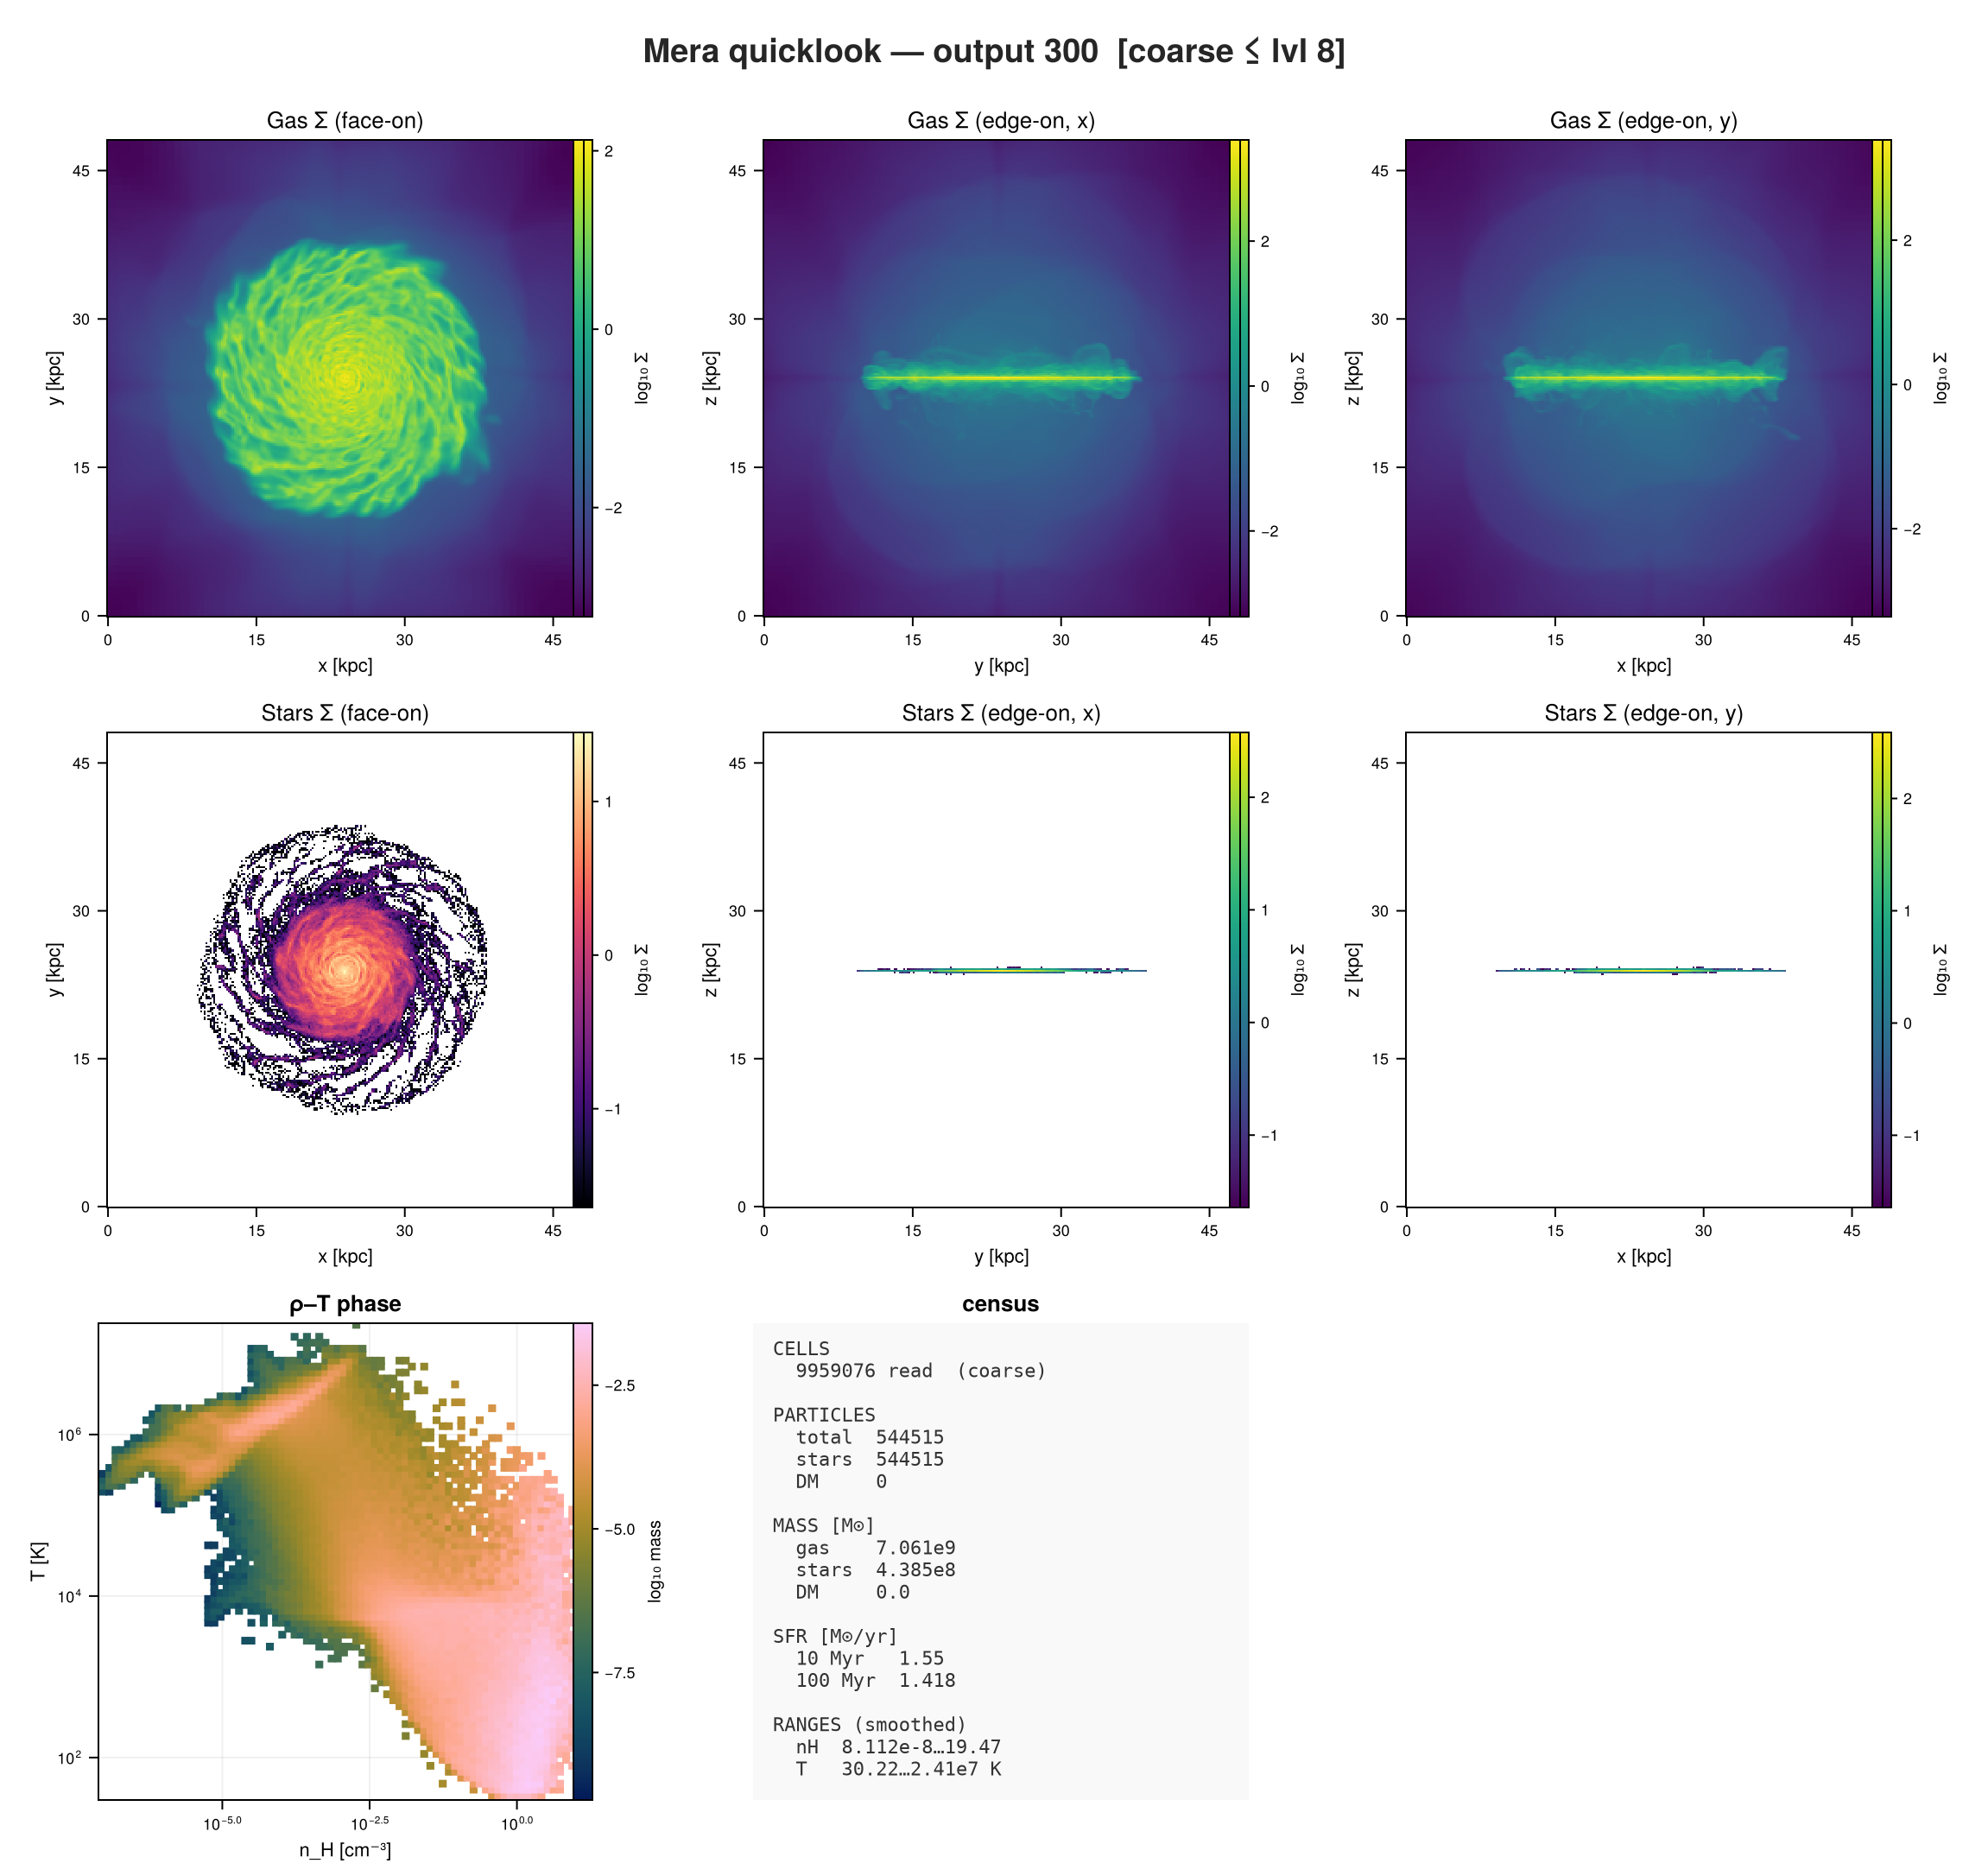

In [8]:
using CairoMakie
quicklookplot(q)

## Step 3: choosing what to read

Three switches control what the call costs. They do **not** all work the same way, and the
difference matters on a run with thousands of files.

### `datatypes`: which components

`[:hydro]` skips the particle read entirely; `[:stars]` or `[:dm]` skip the gas read. On a run
where one of the two dominates, this is the cheapest saving available.

In [9]:
q_gas = quicklook(output; path=path, datatypes=[:hydro], verbose=false)
keys(q_gas.maps)

(:z, :x, :y)

### `directions`: which projection axes

`:z` is face-on for a disk in the xy-plane; `:x` and `:y` are the two edge-on views. It applies to
the gas maps and to the stellar and dark-matter maps alike.

The face-on map keeps the plain key, and edge-on views arrive as `stars_x` / `stars_y` (and
`dm_x` / `dm_y`), so a call asking for two axes of stars returns two stellar maps:

In [10]:
q_stars = quicklook(output; path=path, datatypes=[:stars], directions=[:z, :x], verbose=false)
keys(q_stars.maps)

(:stars, :stars_x)

### `budget` and `lmax`: how much of the AMR hierarchy

`budget` is a target leaf-cell count. If reading every level would exceed it, Mera reads only the
coarse levels, and says so in the dashboard. `lmax` sets that level directly.

Coarsening is **volume-conserving**, so extensive totals stay exact: the gas mass from a budgeted
read is the same number you would get from the full one. Peak quantities are not: the densest and
hottest gas lives in the finest cells, so `nH` and `T` extrema from a coarse read are lower bounds.
The dashboard marks them when that is the case.

In [11]:
q_coarse = quicklook(output; path=path, lmax=8, datatypes=[:hydro], verbose=false)
(cells = q_coarse.ncells, level = q_coarse.lmax_used, gas_mass = q_coarse.budget.gas_mass_Msol)

(cells = 9959076, level = 8, gas_mass = 7.060719565110762e9)

### Gas and particles are read differently

`budget` caps the **gas** read only. Particles are read in full by default, because a particle file
is small next to the AMR hydro, and that is deliberate: it keeps the stellar and dark-matter masses
and the SFR **exact** even when the gas read is coarse.

For runs where reading every particle is itself the cost, `particle_subsample` reads only that
fraction of the particle CPU files, skipping whole files, which cuts I/O and peak memory together.
RAMSES load-balances its domains to roughly equal particle counts, so this reads about that
fraction of the particles; the census, masses and SFR are then scaled by `1/fraction` and flagged
as approximate. The same `subsample` keyword exists on `getparticles`.

In [12]:
q_sub = quicklook(output; path=path, datatypes=[:stars], particle_subsample=0.25, verbose=false)
q_sub.budget

(gas_mass_Msol = nothing, stellar_mass_Msol = 4.7834e8, dm_mass_Msol = 0.0, n_stars = 594020, n_dm = 0, sfr10 = 1.6883, sfr100 = 1.55615, sfr_mean = 1.3437966627699716, has_particles = true)

### How far to trust a coarse read

The distinction that matters is **extensive totals versus peaks**, and it is easy to check rather
than take on trust. Reading the same output at three levels:

In [13]:
using Printf
info = getinfo(output, path, verbose=false)      # header only; the reads happen in the loop
ref = nothing
for l in (8, 7, 6)
    g  = gethydro(info, lmax=l, verbose=false, show_progress=false)
    m  = sum(getvar(g, :mass, :Msol))
    nh = maximum(getvar(g, :rho, :nH))
    T  = maximum(getvar(g, :T, :K))
    global ref = ref === nothing ? (m, nh, T) : ref
    @printf("level %d: %9d cells   gas mass %.6e Msol (%+.4f%%)   nH max %7.3f (%+.1f%%)   T max %.3e (%+.1f%%)\n",
            l, length(g.data), m, 100*(m-ref[1])/ref[1], nh, 100*(nh-ref[2])/ref[2], T, 100*(T-ref[3])/ref[3])
    g = nothing; GC.gc()
end

level 8:   9959076 cells   gas mass 7.060720e+09 Msol (+0.0000%)   nH max  19.474 (+0.0%)   T max 2.410e+07 (+0.0%)


level 7:   1631176 cells   gas mass 7.060720e+09 Msol (+0.0000%)   nH max   8.024 (-58.8%)   T max 9.283e+06 (-61.5%)


level 6:    262144 cells   gas mass 7.060720e+09 Msol (+0.0000%)   nH max   2.804 (-85.6%)   T max 7.540e+06 (-68.7%)


Read that table as two different stories.

**Gas mass does not move.** Not approximately: the error is zero to every digit printed, at every
level. De-refinement is mass- and volume-conserving, so an extensive total is the same number
whether you read two hundred thousand cells or ten million. The same holds for any sum over cells.

**The peaks collapse.** The densest and hottest gas lives in the finest cells, and coarsening
averages it away. One level down already loses most of the density peak, and further down it is
gone by an order of magnitude. So `nH` and `T` extrema from a budgeted read are **lower bounds**,
not estimates. Read at full resolution when you need the true extremes.

Particle quantities behave like the mass rather than like the peaks, because particles are read in
full. They only become approximate under `particle_subsample`, and then by roughly the sampling
noise: the quarter-sample above estimated the star count about 9% high.

The dashboard marks all of this: the read is flagged coarse, the gas mass is labelled
mass-conserving, and the ranges say *peaks smoothed*. Each printed number carries how far to trust
it, which is the point.

## Step 4: the thing that actually costs time on a big run

Here is the part worth understanding before you wait ten minutes for something.

A budgeted read cuts how many **cells** come out of each file. It does not cut how many **files**
get opened. Mera still walks every CPU domain, and on a run with thousands of them that fixed
per-file cost is most of the wall clock.

What does cut the file count is a **spatial range**. RAMSES orders its domains along a Hilbert
curve, so a sub-box maps to a contiguous set of CPU files and Mera opens only those. It reports
how many it skipped:

```
📍 Spatial filtering active: 512 files skipped
```

So on a large run:

- want a cheaper *overview*: lower `budget` or `lmax`, same number of files, fewer cells each
- want a cheaper *region*: give `xrange`/`yrange`/`zrange`, fewer files opened

`quicklook` itself always looks at the whole box. When you want a region, that is a `gethydro`
call with ranges, or a `report` plan.

A related question: can gas cells be subsampled the way particles can? Particles have a
`subsample` keyword that skips whole CPU files, which is unbiased because RAMSES balances roughly
equal particle counts per domain. Gas has no such switch, deliberately. Skipping files would make
a map spatially incomplete, with holes where the skipped domains were. Coarsening the level
instead keeps every part of the box and conserves mass. For gas, level is the right lever.

## Step 5: when `quicklook` is not enough

`quicklook` is deliberately fixed. When you want a different set of panels, `report` lets you
choose them, and it comes with a cost model.

In [14]:
plan = ReportPlan(output; path=path,
                  cards = [ProjectionCard(:hydro, :sd; unit=:Msol_pc2, direction=:z),
                           PhaseCard(:hydro, :rho, :T; weight=:mass, xunit=:nH, yunit=:K)])
preview(plan)

┌─ Mera report PLAN ── output 300 (RAMSES) ── 2 cards ──  (uncalibrated ±2×)


│ level 8 of 10  ⚠ APPROXIMATE (coarse, budget 2000000 cells)   ~1.36e6 hydro cells
├─ card                         kind        datatype     cells     est.t
│  hydro_sd_map                map         hydro       1.36e6    0.08 s
│  rho_T_phase                 phase       hydro       1.36e6    0.01 s
├─ TOTAL  read 4.02 s + compute 0.09 s = 4.1 s  (uncalibrated ±2×)
└─ run: report(plan; output=:ascii|:jld2|:file [, budget_s=…]) ───────


ReportPlan(300, "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES/mw_L10", ReportCard[ProjectionCard(:hydro, :sd, :Msol_pc2, :mass, 256, :z, Any[:bc], :standard, "hydro_sd_map", nothing), PhaseCard(:hydro, :rho, :T, :mass, (80, 80), :log, :log, :nH, :K, "rho_T_phase")], -1, 2000000)

`preview` prints what the plan will do and what it is expected to cost. The estimate comes from a
model of the form

```
read_time ≈ β_open · ncpu  +  β_io · ncells · nvars
```

The first term is the per-file cost, scaled by the number of CPU domains, which is why the
estimate reacts to a run with thousands of files rather than only to its cell count.

Those coefficients start from defaults measured on another machine, so treat an uncalibrated
estimate as within a factor of two. `calibrate!` runs one tiny report and fits them to *your*
disk:

In [15]:
calibrate!(output; path=path)

CostModel(0.005, 3.0e-7, 1.0e-6, 1.0e-8, 5.0e-9, 5.0e-8, 1.0e-6, Dict(:map => 19.392021885441416, :phase => 14.540485944328022, :read => 0.6238442032603373, :profile => 64.4918934967661, :scalar => 1.3610936986940925), true)

In [16]:
# same plan, now with coefficients measured on this machine
estimate(plan)

(per_card = [("hydro_sd_map", :map, :hydro, 1.36352e6, 1.5352896430966594), ("rho_T_phase", :phase, :hydro, 1.36352e6, 0.1037841724762357)], read_s = 2.5066758792508006, compute_s = 1.639073815572895, total_s = 4.145749694823696, level = 8, cells = 1363520, sampled = true, calibrated = true)

If the estimate is larger than you want to wait, `downsample` reduces the plan to fit a target
time, and tells you what it gave up.

In [17]:
downsample(plan, 20.0)

ReportPlan(300, "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES/mw_L10", ReportCard[ProjectionCard(:hydro, :sd, :Msol_pc2, :mass, 256, :z, Any[:bc], :standard, "hydro_sd_map", nothing), PhaseCard(:hydro, :rho, :T, :mass, (80, 80), :log, :log, :nH, :K, "rho_T_phase")], -1, 2000000)

## Which one do I want?

- **Just tell me what this is** → `quicklook(output; path=path)`
- **Only the header, right now** → `quicklook(output; path=path, read=false)`
- **Only the gas, or only the stars** → `datatypes=[:hydro]` / `[:stars]`
- **Edge-on as well as face-on** → `directions=[:z, :x]`
- **It is too slow** → lower `budget` or `lmax` for the whole box; use a spatial range for a region
- **I want specific panels** → `report` with a plan
- **How long will that take?** → `calibrate!` once, then `preview` or `estimate`

## Next steps

- [Hydro: First Inspection](01_hydro_First_Inspection.md), the manual version of what `quicklook`
  automates
- [Bundling Arguments](bundled_arguments.md), for reusing the same window across calls
- [Pipelines](pipelines.md), for loading every component in one call and keeping one
  selection across loading and projection
- [Multi-Threading](multi-threading/multi-threading_intro.md), since the reader threads over CPU
  files and this is where that pays off